<a href="https://colab.research.google.com/github/aditya5203/Artificial-Intelligence-and-Machine-Learning/blob/main/Artificial_Intelligence3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sarcasm Detection in News Headlines Using RNN, LSTM and Word2Vec

## Task 3: Language Task

This notebook implements binary text classification for sarcasm detection in news headlines.

The project includes:

1. Dataset loading and exploration
2. Text preprocessing
3. Cleaned text visualization
4. Tokenization and sequence padding
5. Simple RNN model
6. Bidirectional LSTM model
7. Bidirectional LSTM with pretrained Word2Vec embeddings
8. Model evaluation using accuracy, precision, recall, F1-score, confusion matrix and classification report
9. Error analysis
10. Real-time prediction GUI using Gradio

In [8]:
# ============================================================
# 1. INSTALL REQUIRED LIBRARIES
# ============================================================

!pip install -q contractions
!pip install -q wordcloud
!pip install -q gensim
!pip install -q gradio

In [9]:
# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import os
import re
import time
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import contractions
from wordcloud import WordCloud
from collections import Counter

import nltk
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    Bidirectional,
    Dense,
    Dropout,
    SpatialDropout1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import gensim.downloader as api

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [10]:
# ============================================================
# 3. MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# ============================================================
# 4. SET RANDOM SEED
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed fixed:", SEED)

Random seed fixed: 42


In [12]:
# ============================================================
# FIND ALL CSV FILES IN GOOGLE DRIVE
# ============================================================

import os
import glob

csv_files = glob.glob("/content/drive/MyDrive/**/*.csv", recursive=True)

print("Total CSV files found:", len(csv_files))

for file in csv_files:
    print(file)

Total CSV files found: 8
/content/drive/MyDrive/Crime_Data.csv
/content/drive/MyDrive/Bengaluru_House_Data.csv
/content/drive/MyDrive/Copy of trum_tweet_sentiment_analysis.csv
/content/drive/MyDrive/Colab Notebooks/kc_house_data.csv
/content/drive/MyDrive/Artificial Intelligence and Machine Learning 2026/mnist_3_and_5.csv
/content/drive/MyDrive/Artificial Intelligence and Machine Learning 2026/mnist_0_and_1.csv
/content/drive/MyDrive/Artificial Intelligence and Machine Learning 2026/sarcastic_headlines.csv
/content/drive/MyDrive/Artificial Intelligence and Machine Learning 2026/trum_tweet_sentiment_analysis.csv


In [13]:
# ============================================================
# 5. DATASET PATH SETUP
# ============================================================

import os

DATASET_PATH = "/content/drive/MyDrive/Artificial Intelligence and Machine Learning 2026/sarcastic_headlines.csv"

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError("Dataset path is wrong. Please check the file location again.")

print("Dataset path:", DATASET_PATH)
print("Dataset exists:", os.path.exists(DATASET_PATH))

Dataset path: /content/drive/MyDrive/Artificial Intelligence and Machine Learning 2026/sarcastic_headlines.csv
Dataset exists: True


In [14]:
# ============================================================
# 6. LOAD DATASET
# ============================================================

import pandas as pd

df = pd.read_csv(DATASET_PATH)

print("Dataset shape:", df.shape)
display(df.head())
print("Columns:", df.columns.tolist())

Dataset shape: (28619, 2)


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


Columns: ['headline', 'is_sarcastic']


In [15]:
# ============================================================
# 7. STANDARDIZE COLUMN NAMES
# ============================================================

# Expected columns:
# headline
# is_sarcastic

df.columns = [col.strip() for col in df.columns]

if "headline" not in df.columns:
    possible_text_cols = ["text", "title", "Headline", "headlines"]
    for col in possible_text_cols:
        if col in df.columns:
            df.rename(columns={col: "headline"}, inplace=True)
            break

if "is_sarcastic" not in df.columns:
    possible_label_cols = ["label", "target", "is_sarcasm", "sarcastic"]
    for col in possible_label_cols:
        if col in df.columns:
            df.rename(columns={col: "is_sarcastic"}, inplace=True)
            break

if "headline" not in df.columns or "is_sarcastic" not in df.columns:
    raise ValueError("Dataset must contain headline and is_sarcastic columns.")

df = df[["headline", "is_sarcastic"]]

df["headline"] = df["headline"].astype(str)
df["is_sarcastic"] = df["is_sarcastic"].astype(int)

display(df.head())
print(df.info())

,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   headline      28619 non-null  object
 1   is_sarcastic  28619 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 447.3+ KB
None


In [16]:
# ============================================================
# 8. DATA QUALITY CHECK
# ============================================================

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

# Remove duplicates if available
df = df.drop_duplicates().reset_index(drop=True)

print("\nDataset shape after duplicate removal:", df.shape)

Missing values:
headline        0
is_sarcastic    0
dtype: int64

Duplicate rows: 116

Dataset shape after duplicate removal: (28503, 2)


,Class Label,Class Name,Count,Percentage
0,0,Not Sarcastic,14951,52.454128
1,1,Sarcastic,13552,47.545872


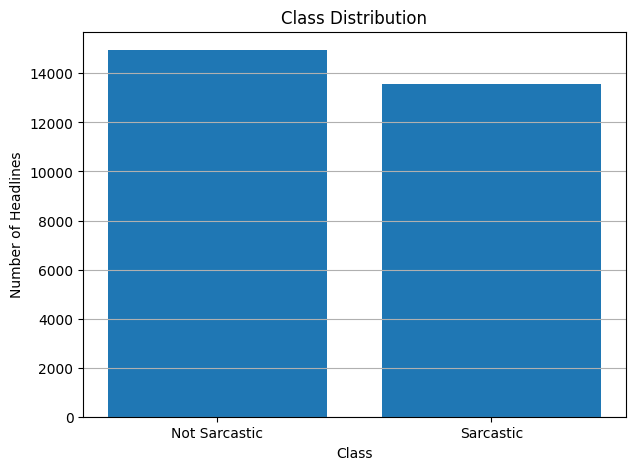

In [17]:
# ============================================================
# 9. CLASS DISTRIBUTION
# ============================================================

class_counts = df["is_sarcastic"].value_counts().sort_index()

class_distribution_df = pd.DataFrame({
    "Class Label": [0, 1],
    "Class Name": ["Not Sarcastic", "Sarcastic"],
    "Count": [
        class_counts.get(0, 0),
        class_counts.get(1, 0)
    ],
    "Percentage": [
        (class_counts.get(0, 0) / len(df)) * 100,
        (class_counts.get(1, 0) / len(df)) * 100
    ]
})

display(class_distribution_df)

plt.figure(figsize=(7, 5))
plt.bar(class_distribution_df["Class Name"], class_distribution_df["Count"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Headlines")
plt.grid(axis="y")
plt.show()

Average headline length: 10.060870785531348
Median headline length: 10.0
90th percentile headline length: 14.0


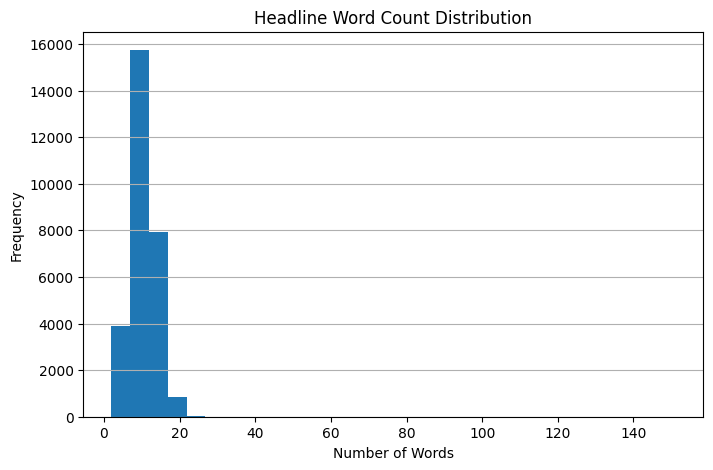

In [18]:
# ============================================================
# 10. HEADLINE LENGTH ANALYSIS BEFORE CLEANING
# ============================================================

df["original_word_count"] = df["headline"].apply(lambda x: len(str(x).split()))

print("Average headline length:", df["original_word_count"].mean())
print("Median headline length:", df["original_word_count"].median())
print("90th percentile headline length:", np.percentile(df["original_word_count"], 90))

plt.figure(figsize=(8, 5))
plt.hist(df["original_word_count"], bins=30)
plt.title("Headline Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.grid(axis="y")
plt.show()

In [19]:
# ============================================================
# 11. TEXT PREPROCESSING FUNCTION
# Lowercase, URL removal, mentions, hashtags, numbers,
# special characters, contractions, stopwords, lemmatization
# ============================================================

stop_words = set(stopwords.words("english"))

# Keep important negation words because they may affect sarcasm meaning
important_words = {"not", "no", "nor", "never"}
stop_words = stop_words - important_words

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text)

    # Expand contractions
    text = contractions.fix(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Remove mentions
    text = re.sub(r"@\w+", " ", text)

    # Remove hashtag symbol but keep hashtag word
    text = re.sub(r"#", "", text)

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize manually
    tokens = text.split()

    # Remove stopwords and lemmatize
    cleaned_tokens = []
    for word in tokens:
        if word not in stop_words:
            lemma = lemmatizer.lemmatize(word)
            cleaned_tokens.append(lemma)

    return " ".join(cleaned_tokens)

In [20]:
# ============================================================
# 12. APPLY TEXT CLEANING
# ============================================================

df["cleaned_headline"] = df["headline"].apply(clean_text)

display(df[["headline", "cleaned_headline", "is_sarcastic"]].head(10))

df["cleaned_word_count"] = df["cleaned_headline"].apply(lambda x: len(str(x).split()))

print("Average cleaned headline length:", df["cleaned_word_count"].mean())
print("Median cleaned headline length:", df["cleaned_word_count"].median())
print("90th percentile cleaned length:", np.percentile(df["cleaned_word_count"], 90))

,headline,cleaned_headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,thirtysomething scientist unveil doomsday cloc...,1
1,dem rep. totally nails why congress is falling...,dem rep totally nail congress falling short ge...,0
2,eat your veggies: 9 deliciously different recipes,eat veggie deliciously different recipe,0
3,inclement weather prevents liar from getting t...,inclement weather prevents liar getting work,1
4,mother comes pretty close to using word 'strea...,mother come pretty close using word streaming ...,1
5,my white inheritance,white inheritance,0
6,5 ways to file your taxes with less stress,way file tax less stress,0
7,richard branson's global-warming donation near...,richard branson global warming donation nearly...,1
8,shadow government getting too large to meet in...,shadow government getting large meet marriott ...,1
9,lots of parents know this scenario,lot parent know scenario,0


Average cleaned headline length: 7.272462547801986
Median cleaned headline length: 7.0
90th percentile cleaned length: 10.0


In [21]:
# ============================================================
# 13. REMOVE EMPTY CLEANED HEADLINES
# ============================================================

before_rows = len(df)

df = df[df["cleaned_headline"].str.strip() != ""].reset_index(drop=True)

after_rows = len(df)

print("Rows before removing empty cleaned text:", before_rows)
print("Rows after removing empty cleaned text:", after_rows)
print("Removed rows:", before_rows - after_rows)

Rows before removing empty cleaned text: 28503
Rows after removing empty cleaned text: 28501
Removed rows: 2


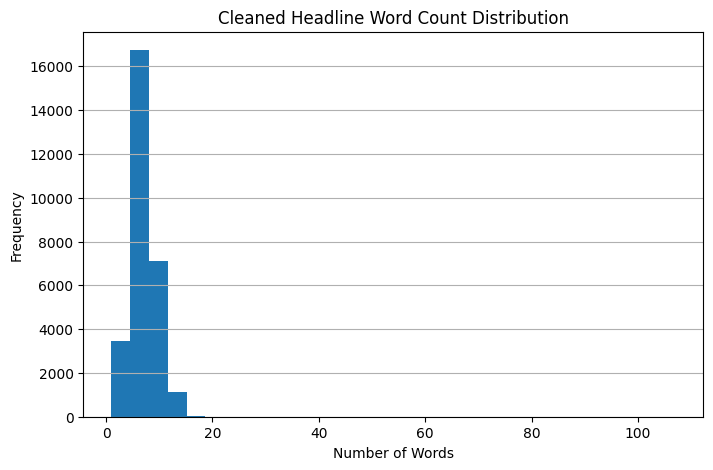

In [22]:
# ============================================================
# 14. CLEANED TEXT LENGTH VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(df["cleaned_word_count"], bins=30)
plt.title("Cleaned Headline Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.grid(axis="y")
plt.show()

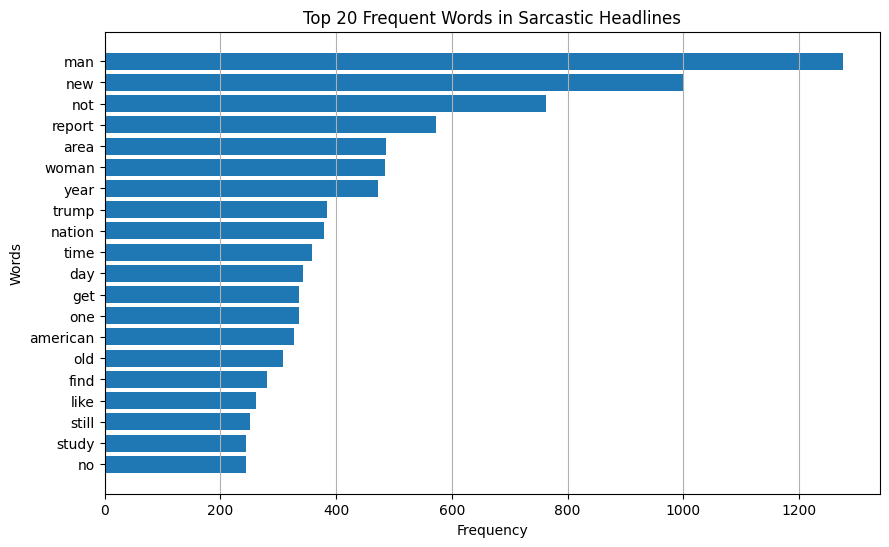

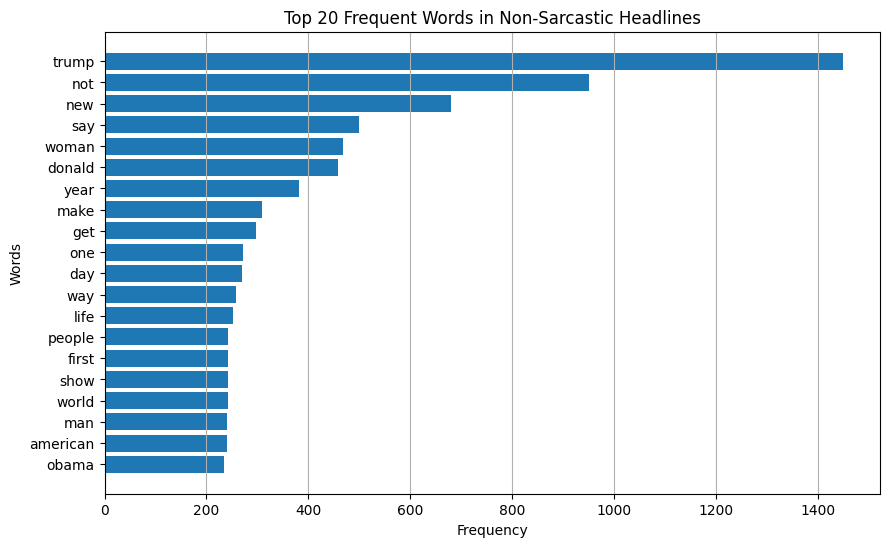

Sarcastic frequent words:


,Word,Frequency
0,man,1275
1,new,1000
2,not,763
3,report,573
4,area,487
5,woman,485
6,year,472
7,trump,384
8,nation,379
9,time,358


Non-sarcastic frequent words:


,Word,Frequency
0,trump,1448
1,not,951
2,new,680
3,say,500
4,woman,467
5,donald,458
6,year,382
7,make,308
8,get,298
9,one,272


In [23]:
# ============================================================
# 15. FREQUENT WORD VISUALIZATION
# ============================================================

sarcastic_text = " ".join(df[df["is_sarcastic"] == 1]["cleaned_headline"].astype(str))
non_sarcastic_text = " ".join(df[df["is_sarcastic"] == 0]["cleaned_headline"].astype(str))

def plot_top_words(text, title, top_n=20):
    words = text.split()
    word_counts = Counter(words)
    common_words = word_counts.most_common(top_n)

    word_df = pd.DataFrame(common_words, columns=["Word", "Frequency"])

    plt.figure(figsize=(10, 6))
    plt.barh(word_df["Word"], word_df["Frequency"])
    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("Words")
    plt.gca().invert_yaxis()
    plt.grid(axis="x")
    plt.show()

    return word_df

sarcastic_words_df = plot_top_words(
    sarcastic_text,
    "Top 20 Frequent Words in Sarcastic Headlines"
)

non_sarcastic_words_df = plot_top_words(
    non_sarcastic_text,
    "Top 20 Frequent Words in Non-Sarcastic Headlines"
)

print("Sarcastic frequent words:")
display(sarcastic_words_df)

print("Non-sarcastic frequent words:")
display(non_sarcastic_words_df)

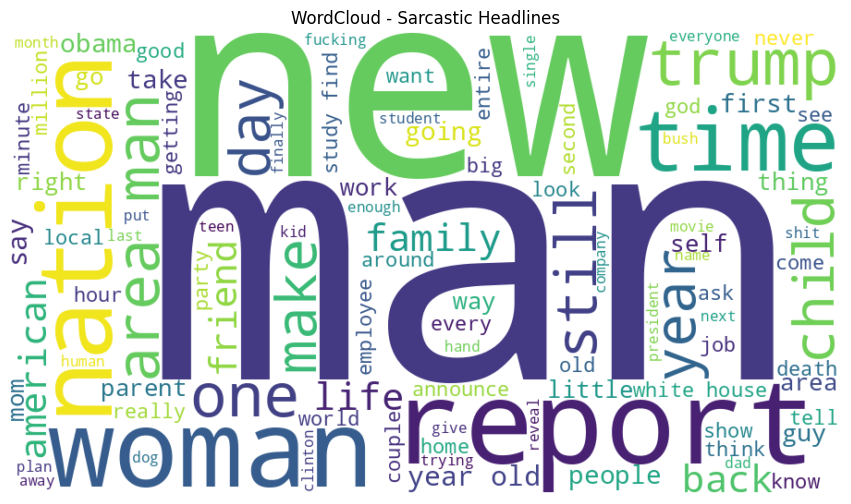

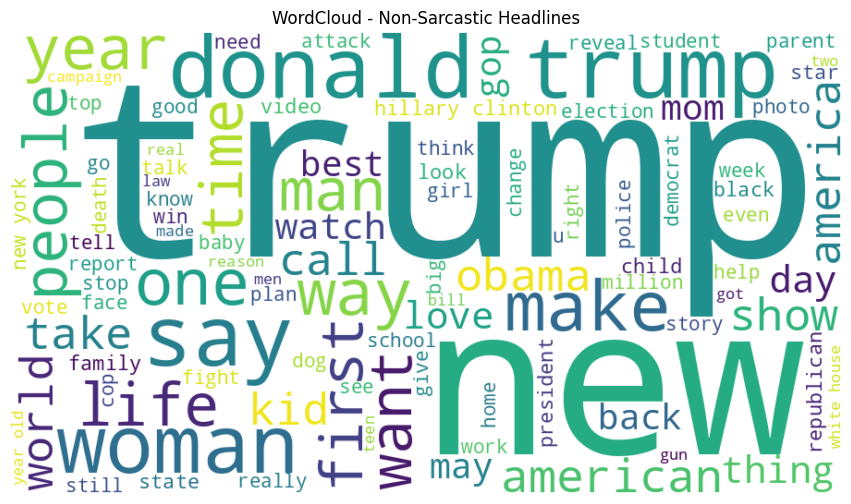

In [24]:
# ============================================================
# 16. WORDCLOUD VISUALIZATION
# ============================================================

sarcastic_wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white",
    max_words=100
).generate(sarcastic_text)

plt.figure(figsize=(12, 6))
plt.imshow(sarcastic_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - Sarcastic Headlines")
plt.show()

non_sarcastic_wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white",
    max_words=100
).generate(non_sarcastic_text)

plt.figure(figsize=(12, 6))
plt.imshow(non_sarcastic_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - Non-Sarcastic Headlines")
plt.show()

In [25]:
# ============================================================
# 17. TRAIN-TEST SPLIT
# 80% training and 20% testing using stratified split
# ============================================================

X = df["cleaned_headline"]
y = df["is_sarcastic"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 22800
Testing samples: 5701

Training class distribution:
is_sarcastic
0    0.524518
1    0.475482
Name: proportion, dtype: float64

Testing class distribution:
is_sarcastic
0    0.524469
1    0.475531
Name: proportion, dtype: float64


In [26]:
# ============================================================
# 18. TOKENIZATION AND PADDING
# Tokenizer fitted only on training data to prevent data leakage
# ============================================================

MAX_VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 14
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    oov_token=OOV_TOKEN
)

tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

y_train_array = np.array(y_train)
y_test_array = np.array(y_test)

word_index = tokenizer.word_index

vocab_size = min(MAX_VOCAB_SIZE, len(word_index) + 1)

print("Vocabulary size used:", vocab_size)
print("Training padded shape:", X_train_pad.shape)
print("Testing padded shape:", X_test_pad.shape)

Vocabulary size used: 10000
Training padded shape: (22800, 14)
Testing padded shape: (5701, 14)


In [27]:
# ============================================================
# 19. CALLBACKS
# ============================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks = [early_stop, reduce_lr]

In [52]:
# ============================================================
# 20. HELPER FUNCTION FOR TRAINING CURVES
# ============================================================

def plot_training_curves(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

In [29]:
# ============================================================
# 21. HELPER FUNCTION FOR MODEL EVALUATION
# ============================================================

def evaluate_text_model(model, X_test_data, y_test_data, model_name):
    y_prob = model.predict(X_test_data)
    y_pred = (y_prob >= 0.5).astype(int).reshape(-1)

    accuracy = accuracy_score(y_test_data, y_pred)
    precision = precision_score(y_test_data, y_pred)
    recall = recall_score(y_test_data, y_pred)
    f1 = f1_score(y_test_data, y_pred)

    print(f"\n{model_name} Results")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)

    print(f"\n{model_name} Classification Report:")
    print(classification_report(
        y_test_data,
        y_pred,
        target_names=["Not Sarcastic", "Sarcastic"]
    ))

    cm = confusion_matrix(y_test_data, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Sarcastic", "Sarcastic"]
    )

    disp.plot()
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "y_prob": y_prob,
        "y_pred": y_pred
    }

In [30]:
# ============================================================
# 22. MODEL 1: SIMPLE RNN WITH TRAINABLE EMBEDDING
# ============================================================

EMBEDDING_DIM_RNN = 128

simple_rnn_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM_RNN,
        input_length=MAX_SEQUENCE_LENGTH
    ),
    SpatialDropout1D(0.2),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.4),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

simple_rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

simple_rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
# ============================================================
# 23. TRAIN SIMPLE RNN
# ============================================================

start_time = time.time()

history_rnn = simple_rnn_model.fit(
    X_train_pad,
    y_train_array,
    validation_split=0.20,
    epochs=15,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

rnn_training_time = time.time() - start_time

print("Simple RNN training time:", rnn_training_time)

Epoch 1/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7274 - loss: 0.5394 - val_accuracy: 0.8024 - val_loss: 0.4335 - learning_rate: 0.0010
Epoch 2/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8885 - loss: 0.2849 - val_accuracy: 0.7779 - val_loss: 0.5765 - learning_rate: 0.0010
Epoch 3/15
569/570 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9396 - loss: 0.1645
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
570/570 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9526 - loss: 0.1360 - val_accuracy: 0.7647 - val_loss: 0.7764 - learning_rate: 0.0010
Epoch 4/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9718 - loss: 0.0852 - val_accuracy: 0.7561 - val_loss: 0.8594 - learning_rate: 5.0000e-04
Epoch 5/15
563/570 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9810 - loss: 0.0604
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
570/570 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9846 - loss: 0.0477 

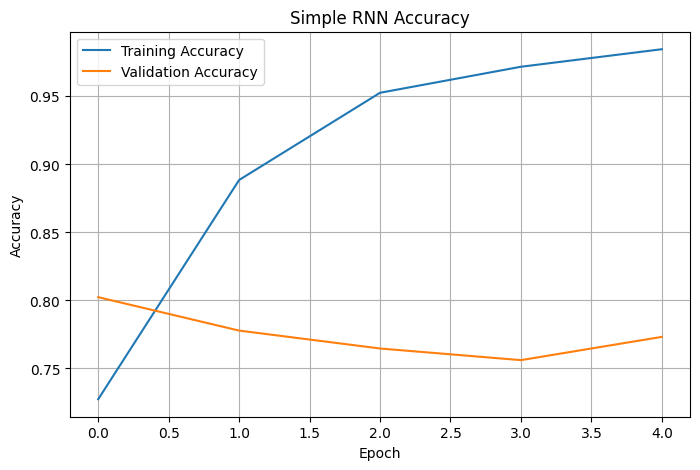

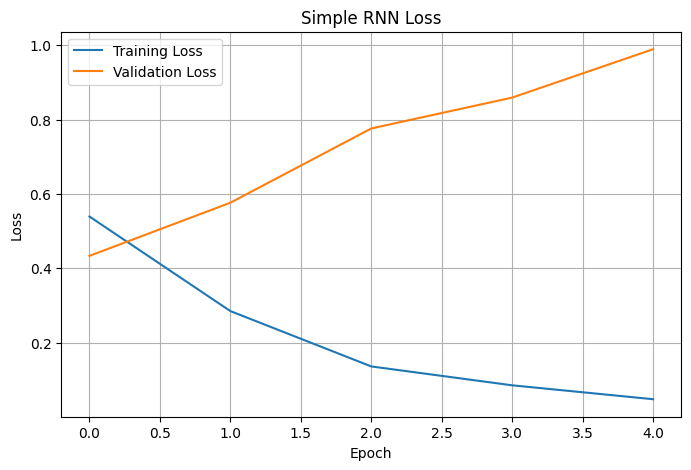

In [32]:
# ============================================================
# 24. SIMPLE RNN TRAINING CURVES
# ============================================================

plot_training_curves(history_rnn, "Simple RNN")

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Simple RNN Results
Accuracy: 0.793369584283459
Precision: 0.7960602549246814
Recall: 0.7602360752489856
F1 Score: 0.7777358490566038

Simple RNN Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.79      0.82      0.81      2990
    Sarcastic       0.80      0.76      0.78      2711

     accuracy                           0.79      5701
    macro avg       0.79      0.79      0.79      5701
 weighted avg       0.79      0.79      0.79      5701



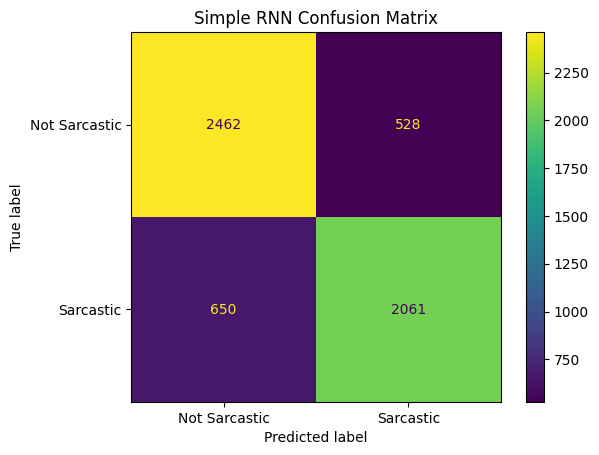

In [33]:
# ============================================================
# 25. SIMPLE RNN EVALUATION
# ============================================================

rnn_results = evaluate_text_model(
    simple_rnn_model,
    X_test_pad,
    y_test_array,
    "Simple RNN"
)

In [34]:
# ============================================================
# 26. MODEL 2: BIDIRECTIONAL LSTM WITH TRAINABLE EMBEDDING
# ============================================================

EMBEDDING_DIM_LSTM = 128

bilstm_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM_LSTM,
        input_length=MAX_SEQUENCE_LENGTH
    ),
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

bilstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

bilstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [35]:
# ============================================================
# 27. TRAIN BIDIRECTIONAL LSTM
# ============================================================

start_time = time.time()

history_bilstm = bilstm_model.fit(
    X_train_pad,
    y_train_array,
    validation_split=0.20,
    epochs=15,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

bilstm_training_time = time.time() - start_time

print("Bidirectional LSTM training time:", bilstm_training_time)

Epoch 1/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.7369 - loss: 0.5149 - val_accuracy: 0.8009 - val_loss: 0.4267 - learning_rate: 0.0010
Epoch 2/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8671 - loss: 0.3123 - val_accuracy: 0.8000 - val_loss: 0.4587 - learning_rate: 0.0010
Epoch 3/15
569/570 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9196 - loss: 0.2101
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
570/570 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9277 - loss: 0.1882 - val_accuracy: 0.7853 - val_loss: 0.5639 - learning_rate: 0.0010
Epoch 4/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9657 - loss: 0.0956 - val_accuracy: 0.7822 - val_loss: 0.8349 - learning_rate: 5.0000e-04
Epoch 5/15
567/570 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9671 - loss: 0.0897
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
570/570 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.9719 - loss: 0

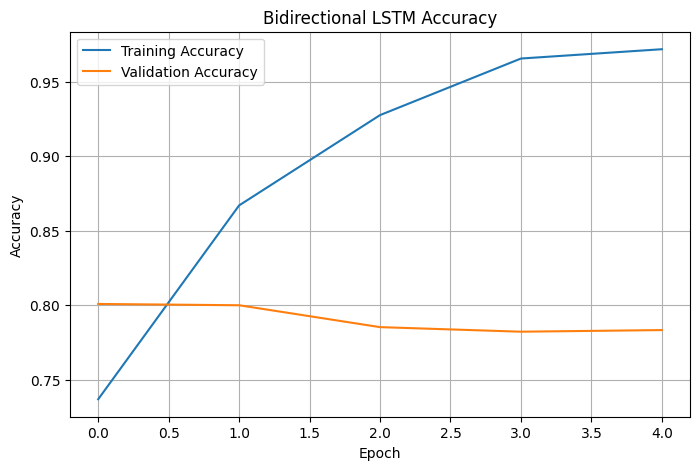

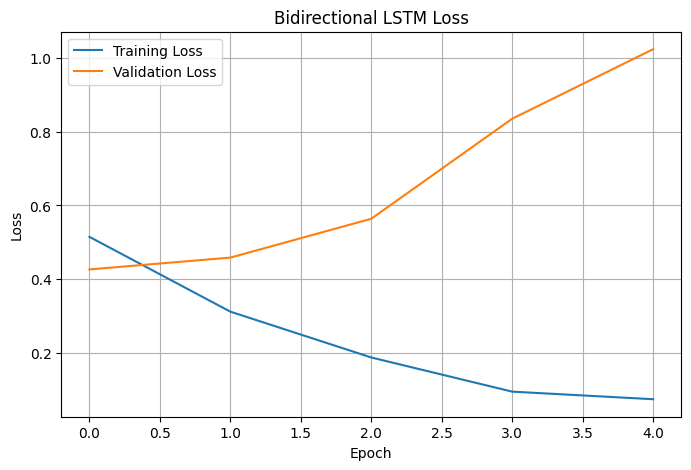

In [36]:
# ============================================================
# 28. BIDIRECTIONAL LSTM TRAINING CURVES
# ============================================================

plot_training_curves(history_bilstm, "Bidirectional LSTM")

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Bidirectional LSTM Results
Accuracy: 0.7938958077530258
Precision: 0.80622009569378
Recall: 0.7458502397639247
F1 Score: 0.7748610844989462

Bidirectional LSTM Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.78      0.84      0.81      2990
    Sarcastic       0.81      0.75      0.77      2711

     accuracy                           0.79      5701
    macro avg       0.80      0.79      0.79      5701
 weighted avg       0.79      0.79      0.79      5701



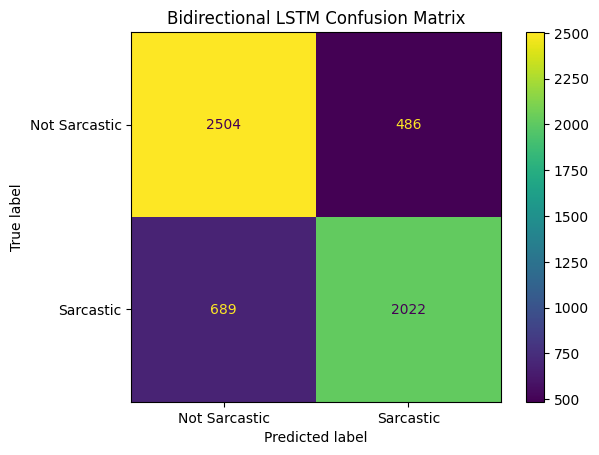

In [37]:
# ============================================================
# 29. BIDIRECTIONAL LSTM EVALUATION
# ============================================================

bilstm_results = evaluate_text_model(
    bilstm_model,
    X_test_pad,
    y_test_array,
    "Bidirectional LSTM"
)

In [38]:
# ============================================================
# 30. LOAD PRETRAINED WORD EMBEDDINGS
# First tries Google News Word2Vec 300.
# If unavailable, uses GloVe 300 as fallback from gensim.
# ============================================================

EMBEDDING_DIM_W2V = 300

print("Loading pretrained embeddings. This may take time...")

try:
    embedding_model = api.load("word2vec-google-news-300")
    EMBEDDING_DIM_W2V = 300
    embedding_name = "word2vec-google-news-300"
    print("Loaded Google News Word2Vec 300 successfully.")

except Exception as e:
    print("Could not load Google News Word2Vec due to:", e)
    print("Loading GloVe 300 fallback...")
    embedding_model = api.load("glove-wiki-gigaword-300")
    EMBEDDING_DIM_W2V = 300
    embedding_name = "glove-wiki-gigaword-300"
    print("Loaded GloVe 300 fallback successfully.")

print("Embedding model used:", embedding_name)
print("Embedding dimension:", EMBEDDING_DIM_W2V)

Loading pretrained embeddings. This may take time...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Loaded Google News Word2Vec 300 successfully.
Embedding model used: word2vec-google-news-300
Embedding dimension: 300


In [39]:
# ============================================================
# 31. CREATE EMBEDDING MATRIX
# ============================================================

embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM_W2V))

found_words = 0
missing_words = 0

for word, i in word_index.items():
    if i >= vocab_size:
        continue

    if word in embedding_model:
        embedding_vector = embedding_model[word]
        embedding_matrix[i] = embedding_vector
        found_words += 1
    else:
        missing_words += 1

print("Embedding matrix shape:", embedding_matrix.shape)
print("Words found in pretrained embedding:", found_words)
print("Words missing from pretrained embedding:", missing_words)
print("Coverage percentage:", round((found_words / vocab_size) * 100, 2), "%")

Embedding matrix shape: (10000, 300)
Words found in pretrained embedding: 9464
Words missing from pretrained embedding: 535
Coverage percentage: 94.64 %


In [40]:
# ============================================================
# 32. MODEL 3: BIDIRECTIONAL LSTM WITH PRETRAINED WORD2VEC
# ============================================================

word2vec_bilstm_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM_W2V,
        weights=[embedding_matrix],
        input_length=MAX_SEQUENCE_LENGTH,
        trainable=False
    ),
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

word2vec_bilstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

word2vec_bilstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,000 (11.44 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,000,000 (11.44 MB)

In [41]:
# ============================================================
# 33. TRAIN WORD2VEC BIDIRECTIONAL LSTM
# ============================================================

start_time = time.time()

history_word2vec = word2vec_bilstm_model.fit(
    X_train_pad,
    y_train_array,
    validation_split=0.20,
    epochs=15,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

word2vec_training_time = time.time() - start_time

print("Word2Vec BiLSTM training time:", word2vec_training_time)

Epoch 1/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.7113 - loss: 0.5563 - val_accuracy: 0.7623 - val_loss: 0.4902 - learning_rate: 0.0010
Epoch 2/15
569/570 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7627 - loss: 0.4910
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
570/570 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.7677 - loss: 0.4816 - val_accuracy: 0.7925 - val_loss: 0.4489 - learning_rate: 0.0010
Epoch 3/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7913 - loss: 0.4344 - val_accuracy: 0.8007 - val_loss: 0.4298 - learning_rate: 5.0000e-04
Epoch 4/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.8077 - loss: 0.4178 - val_accuracy: 0.8086 - val_loss: 0.4145 - learning_rate: 5.0000e-04
Epoch 5/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.8207 - loss: 0.3931 - val_accuracy: 0.8083 - val_loss: 0.4090 - learning_rate: 5.0000e-04
Epoch 6/15
570/570 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.829

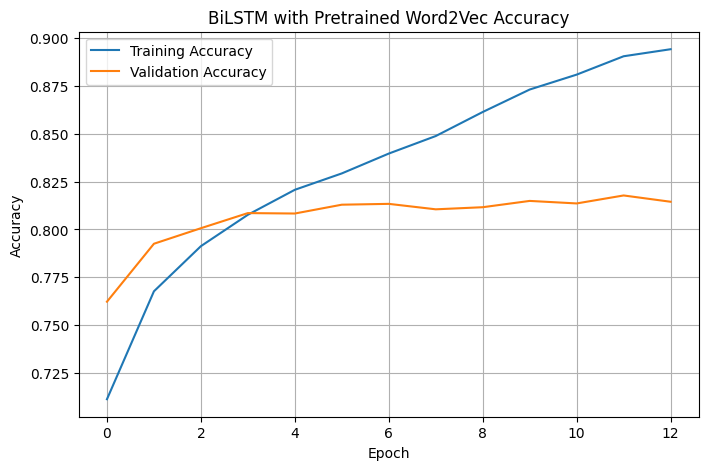

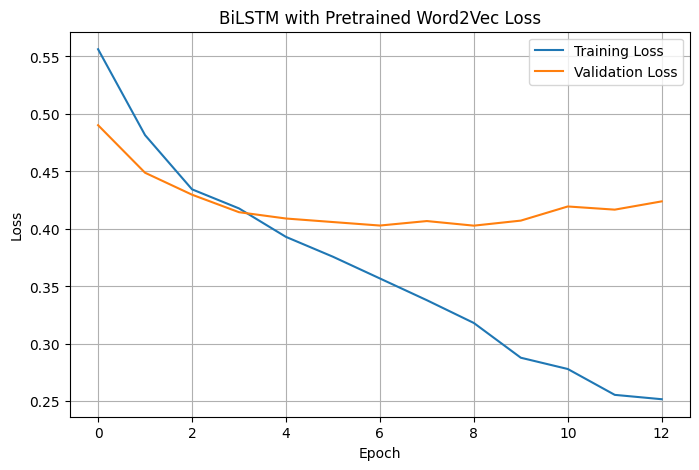

In [42]:
# ============================================================
# 34. WORD2VEC BIDIRECTIONAL LSTM TRAINING CURVES
# ============================================================

plot_training_curves(history_word2vec, "BiLSTM with Pretrained Word2Vec")

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

BiLSTM with Pretrained Word2Vec Results
Accuracy: 0.805648131906683
Precision: 0.8112621359223301
Recall: 0.7705643673921062
F1 Score: 0.7903897086643965

BiLSTM with Pretrained Word2Vec Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.80      0.84      0.82      2990
    Sarcastic       0.81      0.77      0.79      2711

     accuracy                           0.81      5701
    macro avg       0.81      0.80      0.80      5701
 weighted avg       0.81      0.81      0.81      5701



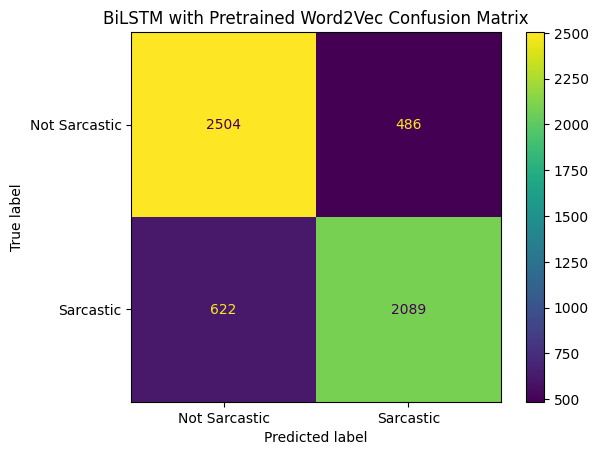

In [43]:
# ============================================================
# 35. WORD2VEC BIDIRECTIONAL LSTM EVALUATION
# ============================================================

word2vec_results = evaluate_text_model(
    word2vec_bilstm_model,
    X_test_pad,
    y_test_array,
    "BiLSTM with Pretrained Word2Vec"
)

In [44]:
# ============================================================
# 36. FINAL MODEL COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame({
    "Model": [
        "Simple RNN",
        "Bidirectional LSTM",
        "BiLSTM + Pretrained Word2Vec"
    ],
    "Accuracy": [
        rnn_results["accuracy"],
        bilstm_results["accuracy"],
        word2vec_results["accuracy"]
    ],
    "Precision": [
        rnn_results["precision"],
        bilstm_results["precision"],
        word2vec_results["precision"]
    ],
    "Recall": [
        rnn_results["recall"],
        bilstm_results["recall"],
        word2vec_results["recall"]
    ],
    "F1 Score": [
        rnn_results["f1"],
        bilstm_results["f1"],
        word2vec_results["f1"]
    ],
    "Training Time Seconds": [
        rnn_training_time,
        bilstm_training_time,
        word2vec_training_time
    ]
})

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,Training Time Seconds
0,Simple RNN,0.793370,0.796060,0.760236,0.777736,20.742885
1,Bidirectional LSTM,0.793896,0.806220,0.745850,0.774861,41.643794
2,BiLSTM + Pretrained Word2Vec,0.805648,0.811262,0.770564,0.790390,100.827069


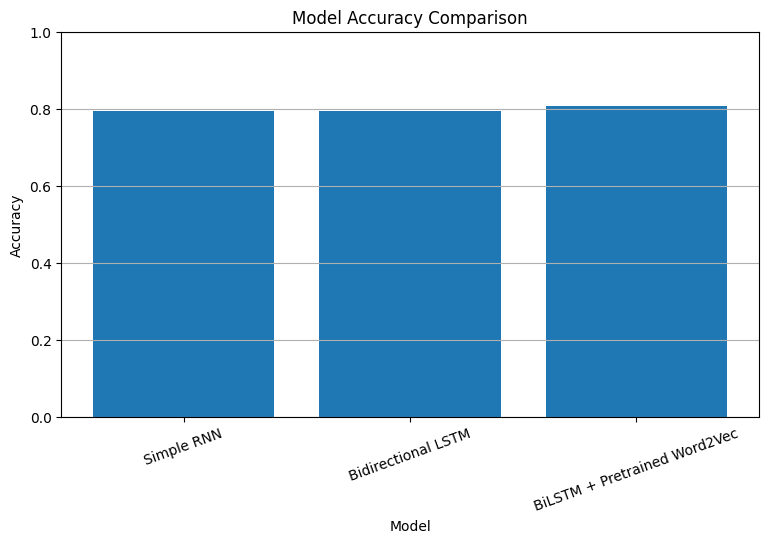

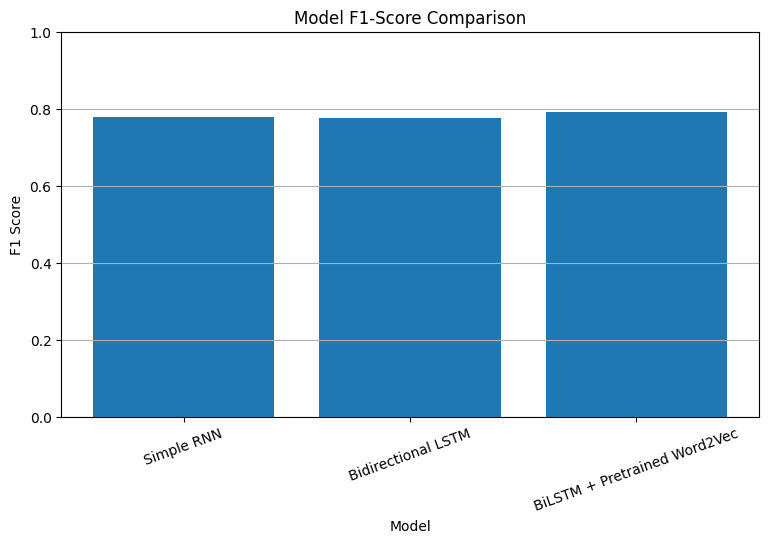

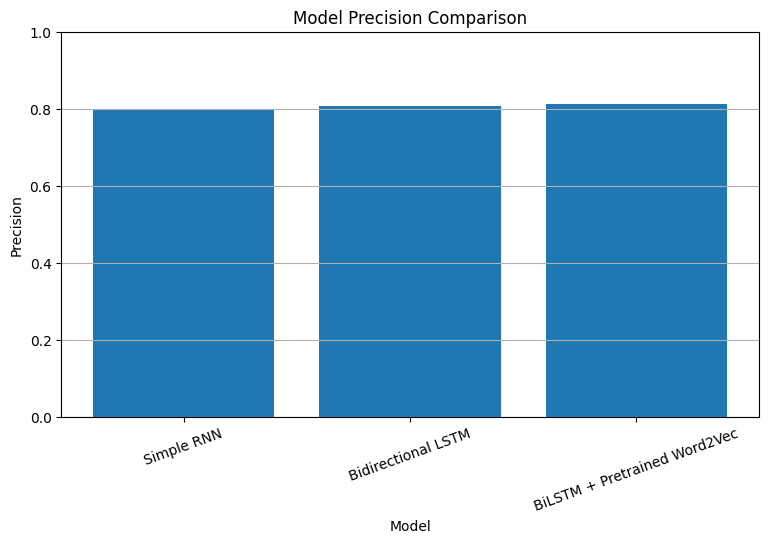

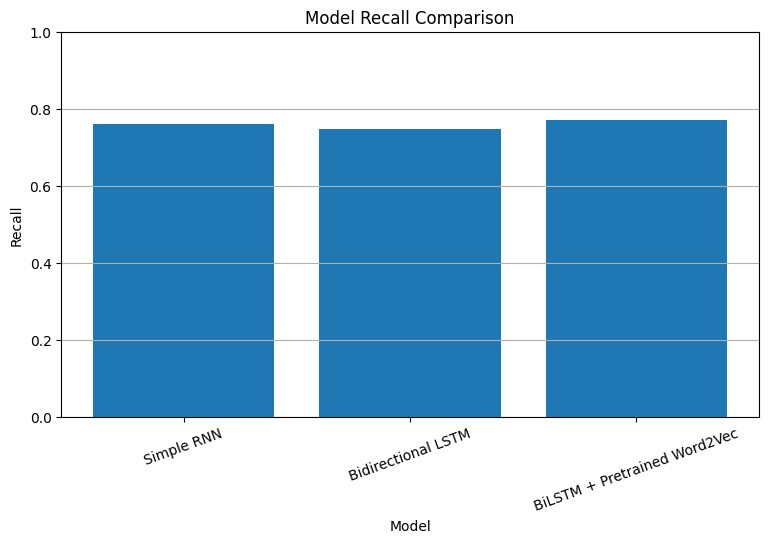

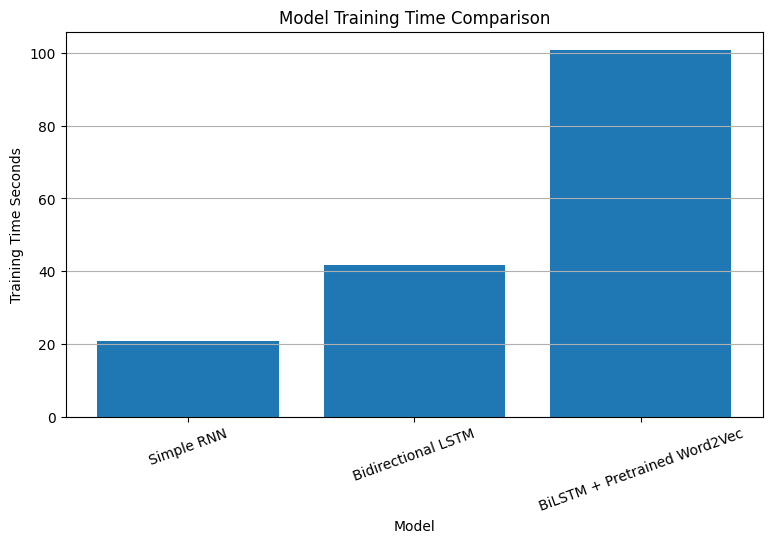

In [45]:
# ============================================================
# 37. FINAL MODEL COMPARISON GRAPHS
# ============================================================

plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["F1 Score"])
plt.title("Model F1-Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["Precision"])
plt.title("Model Precision Comparison")
plt.xlabel("Model")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["Recall"])
plt.title("Model Recall Comparison")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["Training Time Seconds"])
plt.title("Model Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time Seconds")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

In [46]:
# ============================================================
# 38. SELECT BEST MODEL BASED ON F1 SCORE
# ============================================================

best_model_name = results_df.sort_values("F1 Score", ascending=False).iloc[0]["Model"]

print("Best model based on F1 Score:", best_model_name)

if best_model_name == "Simple RNN":
    best_model = simple_rnn_model
    best_results = rnn_results

elif best_model_name == "Bidirectional LSTM":
    best_model = bilstm_model
    best_results = bilstm_results

else:
    best_model = word2vec_bilstm_model
    best_results = word2vec_results

print("Best model selected successfully.")

Best model based on F1 Score: BiLSTM + Pretrained Word2Vec
Best model selected successfully.


In [47]:
# ============================================================
# 39. ERROR ANALYSIS
# Shows incorrect predictions from the best model
# ============================================================

y_prob_best = best_model.predict(X_test_pad)
y_pred_best = (y_prob_best >= 0.5).astype(int).reshape(-1)

wrong_indices = np.where(y_pred_best != y_test_array)[0]

print("Total wrong predictions:", len(wrong_indices))

original_test_texts = X_test_text.reset_index(drop=True)
cleaned_test_texts = X_test_text.reset_index(drop=True)

error_examples = []

for idx in wrong_indices[:10]:
    actual_label = y_test_array[idx]
    predicted_label = y_pred_best[idx]
    confidence = y_prob_best[idx][0]

    error_examples.append({
        "Cleaned Headline": cleaned_test_texts.iloc[idx],
        "Actual": "Sarcastic" if actual_label == 1 else "Not Sarcastic",
        "Predicted": "Sarcastic" if predicted_label == 1 else "Not Sarcastic",
        "Probability of Sarcasm": round(float(confidence), 4)
    })

error_df = pd.DataFrame(error_examples)

display(error_df)

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Total wrong predictions: 1108


,Cleaned Headline,Actual,Predicted,Probability of Sarcasm
0,convict sentenced generating profit private pr...,Sarcastic,Not Sarcastic,0.1031
1,mom bathing suit one giant body eclipsing ruffle,Sarcastic,Not Sarcastic,0.3334
2,california city elect dead man office bizarre ...,Not Sarcastic,Sarcastic,0.7827
3,report countless invasive specie detained epa ...,Sarcastic,Not Sarcastic,0.3988
4,brendan fraser star new pre movie trivia question,Sarcastic,Not Sarcastic,0.0968
5,police department threatens criminal stranger ...,Not Sarcastic,Sarcastic,0.7130
6,superstar sport agent part two,Not Sarcastic,Sarcastic,0.6822
7,bag filled sand still advanced anti flood tech...,Sarcastic,Not Sarcastic,0.3874
8,nurse ignore hospital regulation grant dying m...,Not Sarcastic,Sarcastic,0.8861
9,gorillagram employee shot white house security,Sarcastic,Not Sarcastic,0.2053


# ============================================================
# 39. ERROR ANALYSIS
# Shows incorrect predictions from the best model
# ============================================================

y_prob_best = best_model.predict(X_test_pad)
y_pred_best = (y_prob_best >= 0.5).astype(int).reshape(-1)

wrong_indices = np.where(y_pred_best != y_test_array)[0]

print("Total wrong predictions:", len(wrong_indices))

original_test_texts = X_test_text.reset_index(drop=True)
cleaned_test_texts = X_test_text.reset_index(drop=True)

error_examples = []

for idx in wrong_indices[:10]:
    actual_label = y_test_array[idx]
    predicted_label = y_pred_best[idx]
    confidence = y_prob_best[idx][0]

    error_examples.append({
        "Cleaned Headline": cleaned_test_texts.iloc[idx],
        "Actual": "Sarcastic" if actual_label == 1 else "Not Sarcastic",
        "Predicted": "Sarcastic" if predicted_label == 1 else "Not Sarcastic",
        "Probability of Sarcasm": round(float(confidence), 4)
    })

error_df = pd.DataFrame(error_examples)

display(error_df)

In [48]:
# ============================================================
# 40. REAL-TIME SARCASM PREDICTION FUNCTION
# ============================================================

def predict_sarcasm(headline):
    cleaned = clean_text(headline)

    sequence = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        sequence,
        maxlen=MAX_SEQUENCE_LENGTH,
        padding="post",
        truncating="post"
    )

    probability = best_model.predict(padded, verbose=0)[0][0]

    if probability >= 0.5:
        prediction = "Sarcastic"
    else:
        prediction = "Not Sarcastic"

    return prediction, float(probability), cleaned


# Test prediction
sample_headline = "Local man shocked to learn eating vegetables is healthy"
prediction, probability, cleaned = predict_sarcasm(sample_headline)

print("Original:", sample_headline)
print("Cleaned:", cleaned)
print("Prediction:", prediction)
print("Probability of sarcasm:", probability)

Original: Local man shocked to learn eating vegetables is healthy
Cleaned: local man shocked learn eating vegetable healthy
Prediction: Sarcastic
Probability of sarcasm: 0.9999613761901855


In [49]:
# ============================================================
# 41. GRADIO GUI FOR REAL-TIME PREDICTION
# ============================================================

import gradio as gr

def gradio_predict(headline):
    prediction, probability, cleaned = predict_sarcasm(headline)

    confidence = probability if prediction == "Sarcastic" else 1 - probability

    result = f"""
    Prediction: {prediction}

    Confidence: {confidence * 100:.2f}%

    Probability of Sarcasm: {probability * 100:.2f}%

    Cleaned Text: {cleaned}
    """

    return result

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(
        lines=3,
        placeholder="Enter a news headline here..."
    ),
    outputs="text",
    title="Sarcasm Detection in News Headlines",
    description="Enter a news headline and the trained deep learning model will classify it as sarcastic or not sarcastic."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9476c2c614012bc471.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Final Model Comparison Discussion

Three deep learning models were implemented for sarcasm detection. The Simple RNN model was used as the baseline because it processes text sequentially and can capture basic word-order patterns. However, Simple RNNs can struggle with long-term dependencies and vanishing gradient problems.

The Bidirectional LSTM model improved the architecture by processing headline sequences in both forward and backward directions. This allows the model to understand context from both sides of a word, which is useful for detecting sarcastic intent in short news headlines.

The third model used pretrained Word2Vec embeddings with a Bidirectional LSTM. Pretrained embeddings provide semantic word representations learned from a large corpus, which can improve model understanding compared to randomly initialized embeddings. Since the dataset contains news headlines, pretrained news-domain word embeddings are suitable for this task.

The final comparison table shows the performance of all three models using accuracy, precision, recall, F1-score, and training time. F1-score is especially useful because it balances precision and recall for binary classification. The best-performing model was selected based on F1-score.

In [50]:
# ============================================================
# 42. SAVE MODELS, TOKENIZER AND RESULTS
# ============================================================

import pickle

SAVE_DIR = "/content/task3_sarcasm_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

simple_rnn_model.save(os.path.join(SAVE_DIR, "simple_rnn_sarcasm_model.h5"))
bilstm_model.save(os.path.join(SAVE_DIR, "bilstm_sarcasm_model.h5"))
word2vec_bilstm_model.save(os.path.join(SAVE_DIR, "word2vec_bilstm_sarcasm_model.h5"))

with open(os.path.join(SAVE_DIR, "tokenizer.pkl"), "wb") as f:
    pickle.dump(tokenizer, f)

results_df.to_csv(
    os.path.join(SAVE_DIR, "task3_model_comparison_results.csv"),
    index=False
)

error_df.to_csv(
    os.path.join(SAVE_DIR, "task3_error_analysis_examples.csv"),
    index=False
)

print("All models, tokenizer, results, and error analysis saved successfully.")
print("Saved folder:", SAVE_DIR)

All models, tokenizer, results, and error analysis saved successfully.
Saved folder: /content/task3_sarcasm_outputs


In [51]:
# ============================================================
# 43. ZIP OUTPUT FILES
# ============================================================

import shutil

shutil.make_archive(
    "/content/task3_sarcasm_outputs",
    "zip",
    SAVE_DIR
)

print("ZIP file created at: /content/task3_sarcasm_outputs.zip")

ZIP file created at: /content/task3_sarcasm_outputs.zip
